# 01 · Complex SLC Simulation

Reproduces **Fig. 2** of De Zan et al. (2014): real and imaginary parts of the
relative dielectric constant as a function of volumetric soil moisture at L-band
(1.4 GHz), for soil with 51 % sand and 13 % clay.

Also demonstrates the Zheng & Fattahi (2026) SLC simulation (Eq. 3, Table 1)
and shows the amplitude/phase of a single simulated pixel.

---
**References**
- De Zan, F., Parizzi, A., Prats-Iraola, P., & López-Dekker, P. (2014).
  *A SAR interferometric model for soil moisture.*
  IEEE Transactions on Geoscience and Remote Sensing, 52(1), 418–425.
  https://doi.org/10.1109/TGRS.2013.2241069
- Zheng, Y., & Fattahi, H. (2026).
  *Modeling, prediction, and retrieval of surface soil moisture from InSAR closure phase.*
  Remote Sensing of Environment, 333, 115104.
  https://doi.org/10.1016/j.rse.2025.115104
- Hallikainen, M. T., Ulaby, F. T., Dobson, M. C., El-Rayes, M. A., & Wu, L.-K. (1985).
  *Microwave dielectric behavior of wet soil – Part 1.*
  IEEE Transactions on Geoscience and Remote Sensing, GE-23(1), 25–34.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from navasar.dielectric import hallikainen_dielectric, kz_soil
from navasar.slc import simulate_slc

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## Fig. 2 — Dielectric constant vs soil moisture (De Zan 2014)

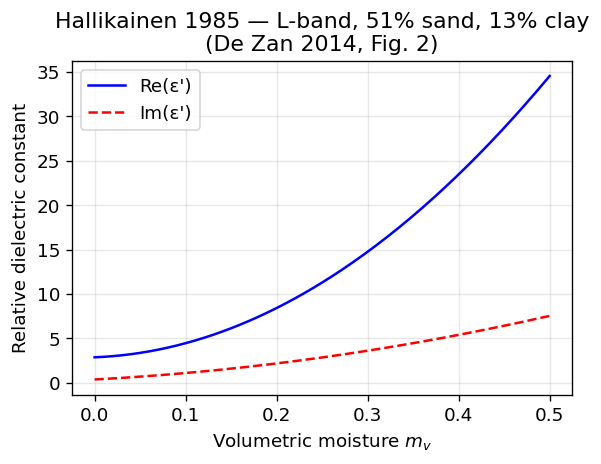

In [2]:
mv = np.linspace(0, 0.5, 200)
eps = hallikainen_dielectric(mv, freq_ghz=1.4, sand=0.51, clay=0.13)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(mv, eps.real, 'b-',  label="Re(ε')")
ax.plot(mv, eps.imag, 'r--', label="Im(ε')")
ax.set_xlabel('Volumetric moisture $m_v$')
ax.set_ylabel('Relative dielectric constant')
ax.set_title('Hallikainen 1985 — L-band, 51% sand, 13% clay\n(De Zan 2014, Fig. 2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../examples/fig02_dielectric_constant.png', dpi=150)
plt.show()

## Vertical wavenumber kz in soil vs moisture

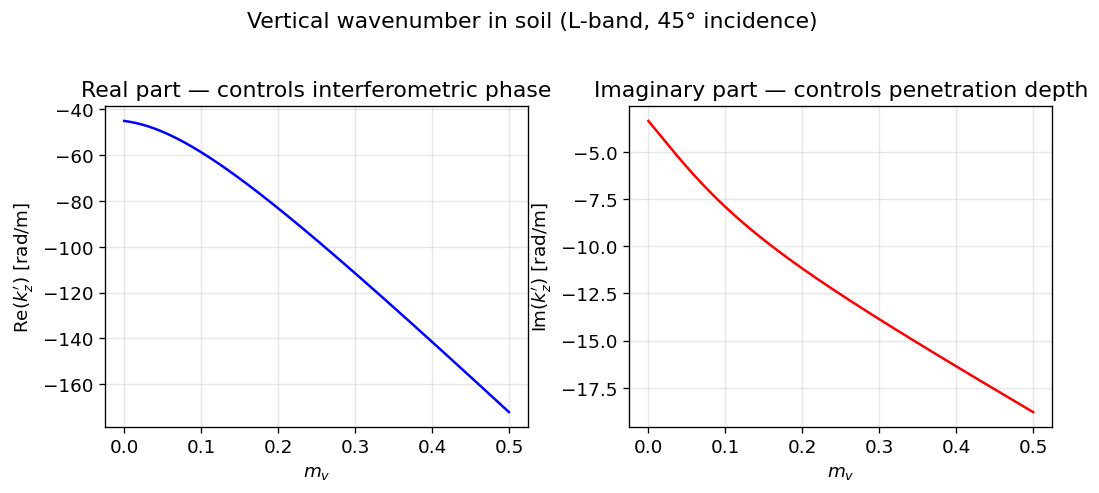

In [3]:
kz = kz_soil(mv, freq_ghz=1.4, theta_inc_deg=45.0, sand=0.51, clay=0.13)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(mv, kz.real, 'b')
axes[0].set_xlabel('$m_v$'); axes[0].set_ylabel("Re($k_z'$) [rad/m]")
axes[0].set_title('Real part — controls interferometric phase')
axes[0].grid(True, alpha=0.3)

axes[1].plot(mv, kz.imag, 'r')
axes[1].set_xlabel('$m_v$'); axes[1].set_ylabel("Im($k_z'$) [rad/m]")
axes[1].set_title('Imaginary part — controls penetration depth')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Vertical wavenumber in soil (L-band, 45° incidence)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_kz_vs_moisture.png', dpi=150)
plt.show()

## SLC simulation — Zheng & Fattahi (2026) Eq. 3

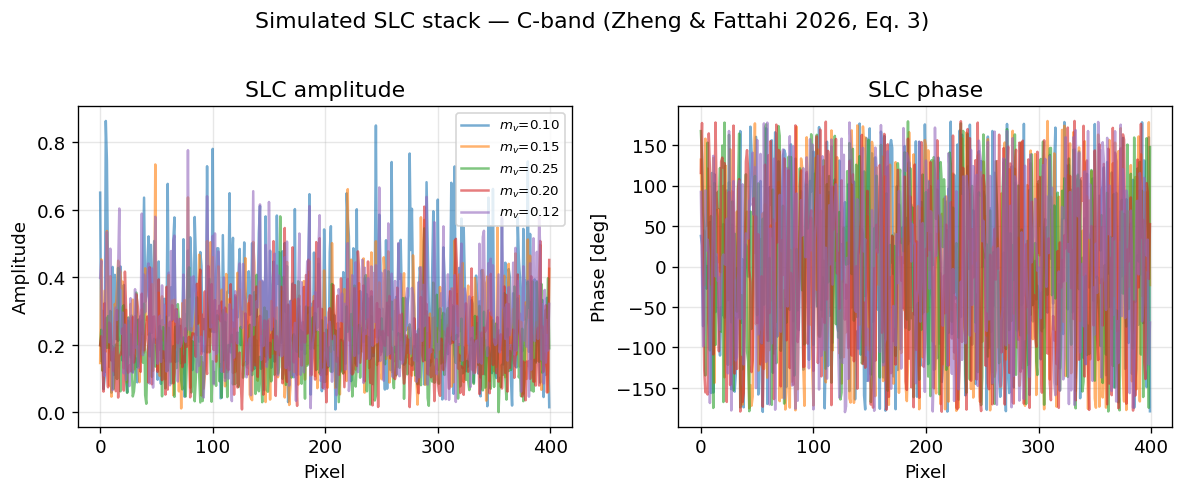

In [4]:
# Simulate 5 acquisitions at different moisture levels
mv_acq = np.array([0.10, 0.15, 0.25, 0.20, 0.12])
slc_stack = simulate_slc(
    mv_acq, freq_ghz=5.0, sand=0.51, clay=0.13,
    n_pixels=400, n_layers=200, max_depth=0.30
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for t, mv_val in enumerate(mv_acq):
    axes[0].plot(np.abs(slc_stack[t]), alpha=0.6, label=f'$m_v$={mv_val:.2f}')
    axes[1].plot(np.angle(slc_stack[t], deg=True), alpha=0.6)

axes[0].set_xlabel('Pixel'); axes[0].set_ylabel('Amplitude')
axes[0].set_title('SLC amplitude'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Pixel'); axes[1].set_ylabel('Phase [deg]')
axes[1].set_title('SLC phase')
for ax in axes: ax.grid(True, alpha=0.3)
plt.suptitle('Simulated SLC stack — C-band (Zheng & Fattahi 2026, Eq. 3)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_slc_simulation.png', dpi=150)
plt.show()